# Hypothesis Testing: Manual Car vs Automatic <hr style = "border:2.5px solid #e22424ff"> </hr>

<b>Camorahan Lorenz V.</b>
<br>T09 - A</br>

In [ ]:
# imports and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower
from statsmodels.stats.power import TTestIndPower

In [ ]:
# Load and Clean Data
df = pd.read_csv(r"dataset\auto_v_manual.csv",
                 delimiter=",")
                 
# Filter for First Owner only
df_filtered = df[df['Owner'] == 'First']

print(f"Dataset size after filtering for First Owner: {df_filtered.shape[0]} rows")

Dataset size after filtering for First Owner: 1619 rows


In [112]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [113]:
# summary of statistics
# Transposing the describe table so stats are rows and Transmission types are columns
df.groupby('Transmission')['Price'].describe().T

Transmission,Automatic,Manual
count,9.260000e+02,1.133000e+03
mean,2.979057e+06,6.600644e+05
std,3.131865e+06,4.586647e+05
min,1.850000e+05,4.900000e+04
25%,1.125000e+06,3.750000e+05
50%,2.100000e+06,5.510000e+05
75%,3.893750e+06,8.000000e+05
max,3.500000e+07,7.050000e+06


# Data Outliers Visualization

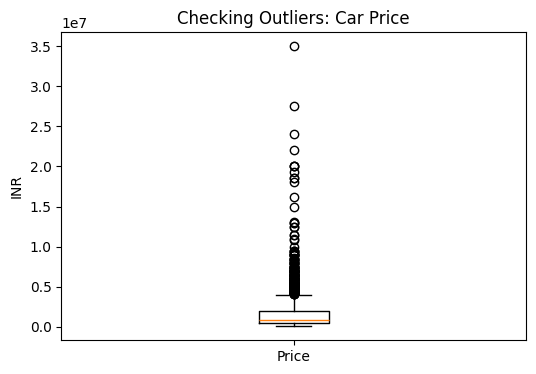

In [114]:
# plotting Car Price
plt.figure(figsize=(6, 4))
plt.boxplot(df['Price'], tick_labels=['Price'])
plt.title("Checking Outliers: Car Price")
plt.ylabel("INR")
plt.show()

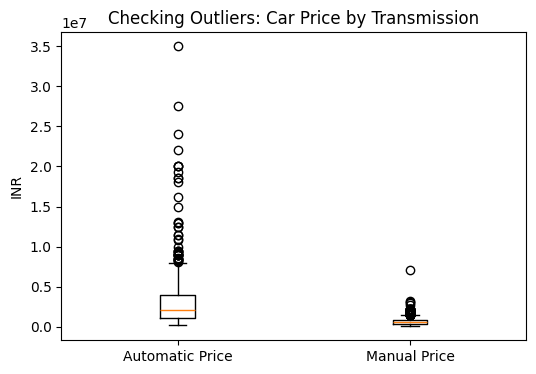

In [115]:
# plotting Price by Transmission Status
auto_price_raw = df[df['Transmission'] == 'Automatic']['Price']
manual_price_raw = df[df['Transmission'] == 'Manual']['Price']

plt.figure(figsize=(6, 4))
plt.boxplot([auto_price_raw, manual_price_raw], tick_labels=['Automatic Price', 'Manual Price'])
plt.title("Checking Outliers: Car Price by Transmission")
plt.ylabel("INR")
plt.show()

# Data Cleaning

Dataset size before removing outliers: 2059 rows


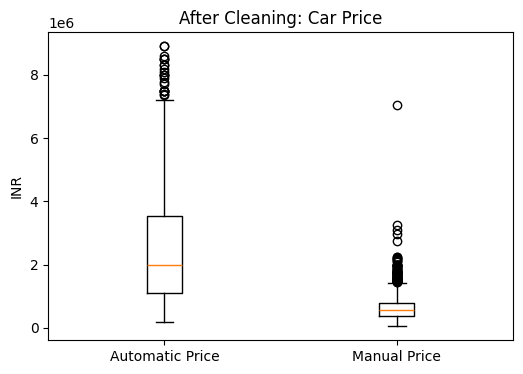

In [116]:
# Print size before removing outliers
print(f"Dataset size before removing outliers: {df.shape[0]} rows")

# removing price outliers using z-score
z_price = stats.zscore(df['Price'])
price_outliers = (z_price < -3) | (z_price > 3)
df = df[~price_outliers]

# re-plot clean Price
auto_price_clean = df[df['Transmission'] == 'Automatic']['Price']
manual_price_clean = df[df['Transmission'] == 'Manual']['Price']

plt.figure(figsize=(6, 4))
plt.boxplot([auto_price_clean, manual_price_clean], tick_labels=['Automatic Price', 'Manual Price'])
plt.title("After Cleaning: Car Price")
plt.ylabel("INR")
plt.show()

In [117]:
# Print size after removing outliers
print(f"Dataset size after removing outliers: {df.shape[0]} rows")

Dataset size after removing outliers: 2027 rows


# NORMALIZATION (Central Limit Theorem)

In [ ]:
np.random.seed(42) # For reproducibility
sample_size = 35
num_samples = 1000

# Generating sample means
auto_price_means = [auto_price_clean.sample(sample_size, replace=True).mean() for _ in range(num_samples)]
manual_price_means = [manual_price_clean.sample(sample_size, replace=True).mean() for _ in range(num_samples)]

In [124]:
# normalized dataframe of the sample means
clt_df = pd.DataFrame({
    'Automatic_Price': auto_price_means,
    'Manual_Price': manual_price_means
})

print(clt_df.describe())

       Automatic_Price   Manual_Price
count     1.000000e+03    1000.000000
mean      2.557453e+06  662030.089914
std       3.232664e+05   76769.045362
min       1.482743e+06  488714.228571
25%       2.336407e+06  607749.900000
50%       2.541028e+06  655699.928571
75%       2.776714e+06  703578.557143
max       3.758257e+06  980628.457143


# 2-Sample t-Test
## Normality proof between Automatic and Manual Car Prices

In [120]:
print("Automatic Car Price:")
w_stat_a, p_a = stats.shapiro(clt_df['Automatic_Price'])
print(f"w_stat: {w_stat_a:.4f}")
print(f"P-value: {p_a:.4f}")

# verdict
alpha = 0.05
if p_a < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

print("\nManual Car Price:")
w_stat_m, p_m = stats.shapiro(clt_df['Manual_Price'])
print(f"w_stat: {w_stat_m:.4f}")
print(f"P-value: {p_m:.4f}")

# verdict
if p_m < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

Automatic Car Price:
w_stat: 0.9978
P-value: 0.2241
Normal data

Manual Car Price:
w_stat: 0.9760
P-value: 0.0000
Non-normal data


In [121]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_auto = var_manual
Ha: var_auto != var_manual
"""

var_a = clt_df['Automatic_Price'].var(ddof=1)
var_m = clt_df['Manual_Price'].var(ddof=1)

# Manual F-stat calculation
if var_a > var_m:
    f_stat = var_a / var_m
else:
    f_stat = var_m / var_a

print(f'F-statistic = {f_stat:.4f}')

# Degrees of Freedom
dof_a = clt_df['Automatic_Price'].count() - 1
dof_m = clt_df['Manual_Price'].count() - 1

# probability value
p_val_f = 1 - stats.f.cdf(f_stat, dof_a, dof_m)
print(f'p-value = {p_val_f:.4f}')

# verdict
alpha = 0.05
if p_val_f < alpha:
    # reject null hypothesis
    print("unequal variances")
    use_eq_var = False
else:
    # fail to reject null hypothesis
    print("equal variances")
    use_eq_var = True

F-statistic = 17.7316
p-value = 0.0000
unequal variances


In [122]:
"""
2- Sample T-Test for Independent Samples
----------------------------------------
Ho: Automatic_Price <= Manual_Price
Ha: Automatic_Price > Manual_Price
"""

t_stat2, p_value2 = stats.ttest_ind(clt_df['Automatic_Price'], clt_df['Manual_Price'], 
                                   alternative='greater', equal_var=use_eq_var)

print(f't_stat = {t_stat2:.4f}')
print(f'p_value = {p_value2:.4f}')

# verdict
alpha = 0.05
if p_value2 < alpha:
    # reject null hypothesis
    print("The price of Automatic cars is significantly higher than Manual cars.")
else:
    # fail to reject null hypothesis
    print("No significant difference in price between Automatic and Manual cars.")

t_stat = 180.3982
p_value = 0.0000
The price of Automatic cars is significantly higher than Manual cars.


In [123]:
"""
Effect Size and Power
------------------
Ho: u_auto = u_manual
Ha: u_auto > u_manual
"""

# Manual Cohen's d formula
a_mean = clt_df['Automatic_Price'].mean()
m_mean = clt_df['Manual_Price'].mean()
a_std = clt_df['Automatic_Price'].std(ddof=1)

d = abs((a_mean - m_mean) / a_std)
print(f"Cohen's d: {d:.4f}")

# power of a test
# Note: switched to TTestIndPower for independent 2-sample
power = TTestIndPower().power(
    effect_size = d, 
    nobs1 = clt_df['Automatic_Price'].count(),
    alpha = 0.05,
    ratio = clt_df['Manual_Price'].count() / clt_df['Automatic_Price'].count(),
    alternative = "larger"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 5.8633
Power of the test: 100.00%
